# DRAWER Hacker - Casey Rodgers

## Set up

### References:
- My CS 444 assignment to set up Colab
- https://arxiv.org/abs/2504.15278
- https://thepythoncode.com/article/image-segmentation-using-huggingface-transformers-python
- https://www.geeksforgeeks.org/python/python-pillow-flip-and-rotate-images/
- https://github.com/JasonQSY/3DOI
- https://thelinuxcode.com/load-pt-pth-file-pytorch/
- https://docs.pytorch.org/vision/stable/models.html
- Duck.ai
- https://www.geeksforgeeks.org/python/python-create-video-using-multiple-images-using-opencv/

### Imports


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
from torchvision import transforms
from transformers import pipeline, SegformerImageProcessor, SegformerForSemanticSegmentation
import requests
from PIL import Image
import urllib.parse as parse
import os
import yaml
from omegaconf import DictConfig, OmegaConf

In [6]:
import torch
import torch.nn.functional as F
import os
import numpy as np
import hydra
import logging
import submitit
import pickle
import collections
from omegaconf import DictConfig, OmegaConf
from accelerate import Accelerator, DistributedType, DistributedDataParallelKwargs
import pdb
import cv2
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

In [7]:
from threedoi.monoarti.monoarti.model import build_model
from threedoi.monoarti.monoarti.detr.misc import interpolate
from threedoi.monoarti.monoarti.visualizer import Visualizer
from threedoi.monoarti.monoarti.detr import box_ops
from threedoi.monoarti.monoarti import axis_ops, depth_ops

In [8]:
import cv2
import numpy as np

In [9]:
from diffusers import StableDiffusionPipeline

## Segment the Door

### Load the Image

(1280, 960)
(960, 1280, 3)


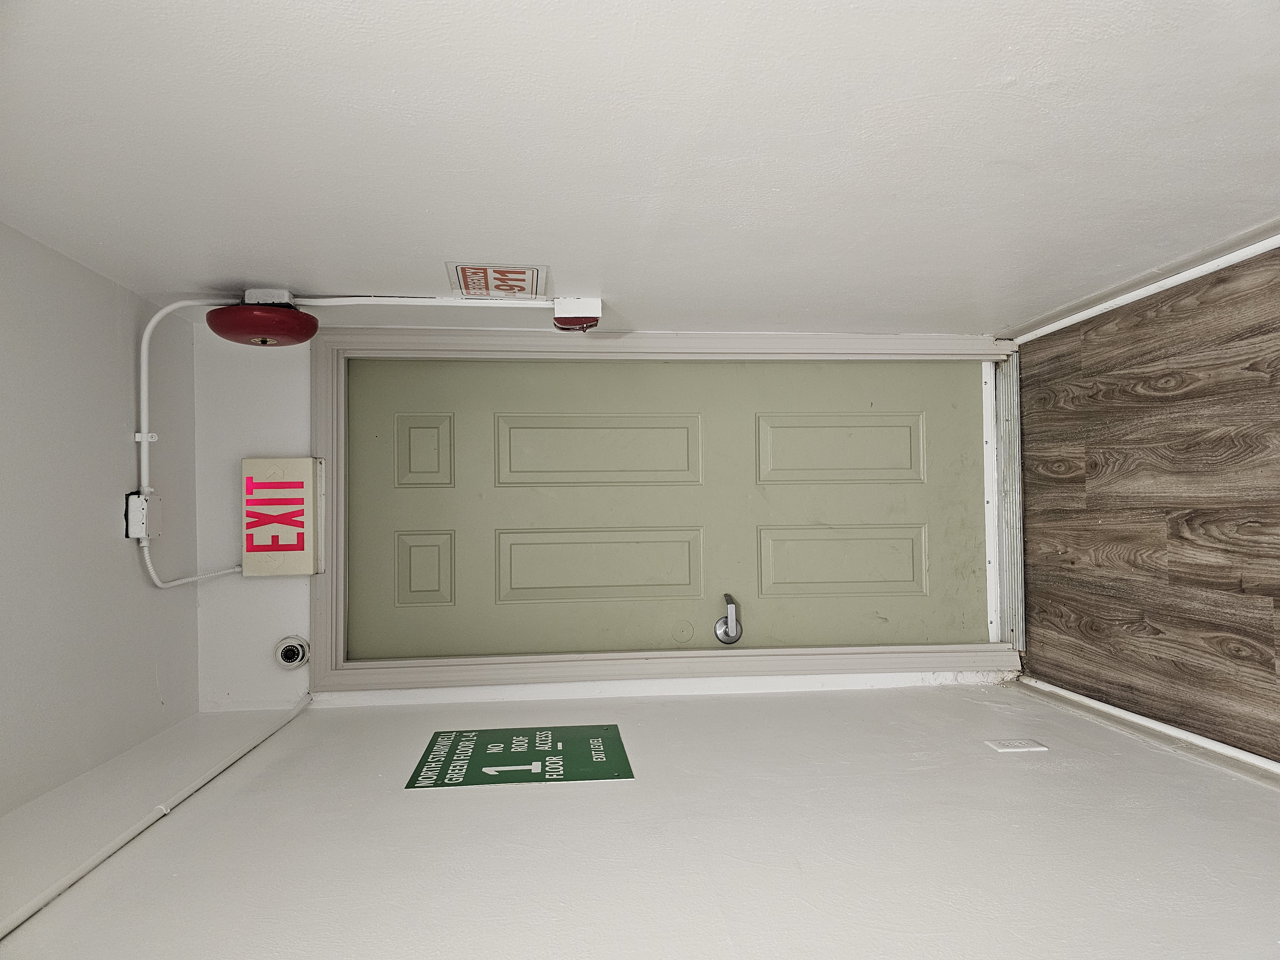

In [12]:
## Open the Image
image = Image.open("door.jpg")
image = image.resize((1280, 960))
print(image.size)
print(np.array(image).shape)
image

### Helper Functions

In [14]:
def color_palette():
  """Color palette to map each class to its corresponding color."""
  return [[0, 128, 128],
          [255, 170, 0],
          [161, 19, 46],
          [118, 171, 47],
          [255, 255, 0],
          [84, 170, 127],
          [170, 84, 127],
          [33, 138, 200],
          [255, 84, 0]]


def overlay_segments(image, seg_mask):
  """Return different segments predicted by the model overlaid on image."""
  H, W = seg_mask.shape
  image_mask = np.zeros((H, W, 3), dtype=np.uint8)
  colors = np.array(color_palette())
  # convert to a pytorch tensor if seg_mask is not one already
  seg_mask = seg_mask if torch.is_tensor(seg_mask) else torch.tensor(seg_mask)
  unique_labels = torch.unique(seg_mask)
  # map each segment label to a unique color
  for i, label in enumerate(unique_labels):
    image_mask[seg_mask == label.item(), :] = colors[i]
  image = np.array(image)
  # percentage of original image in the final overlaid iamge
  img_weight = 0.5 
  # overlay input image and the generated segment mask
  img = img_weight * np.array(image) * 255 + (1 - img_weight) * image_mask
  return img.astype(np.uint8)


def replace_label(mask, label):
  """Replace the segment masks values with label."""
  mask = np.array(mask)
  mask[mask == 255] = label
  return mask

### Image segmentation using DeepLabV3

In [16]:
# load the entire image segmentation pipeline
img_segmentation_pipeline = pipeline('image-segmentation', 
                                     model="nvidia/segformer-b0-finetuned-ade-512-512")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
C:\Anaconda\envs\monoarti\lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)
Device set to use cpu


In [17]:
output = img_segmentation_pipeline(image)
output

[{'score': None,
  'label': 'wall',
  'mask': <PIL.Image.Image image mode=L size=960x1280>},
 {'score': None,
  'label': 'floor',
  'mask': <PIL.Image.Image image mode=L size=960x1280>},
 {'score': None,
  'label': 'ceiling',
  'mask': <PIL.Image.Image image mode=L size=960x1280>},
 {'score': None,
  'label': 'door',
  'mask': <PIL.Image.Image image mode=L size=960x1280>},
 {'score': None,
  'label': 'signboard',
  'mask': <PIL.Image.Image image mode=L size=960x1280>}]

(960, 1280)
(1280, 960)


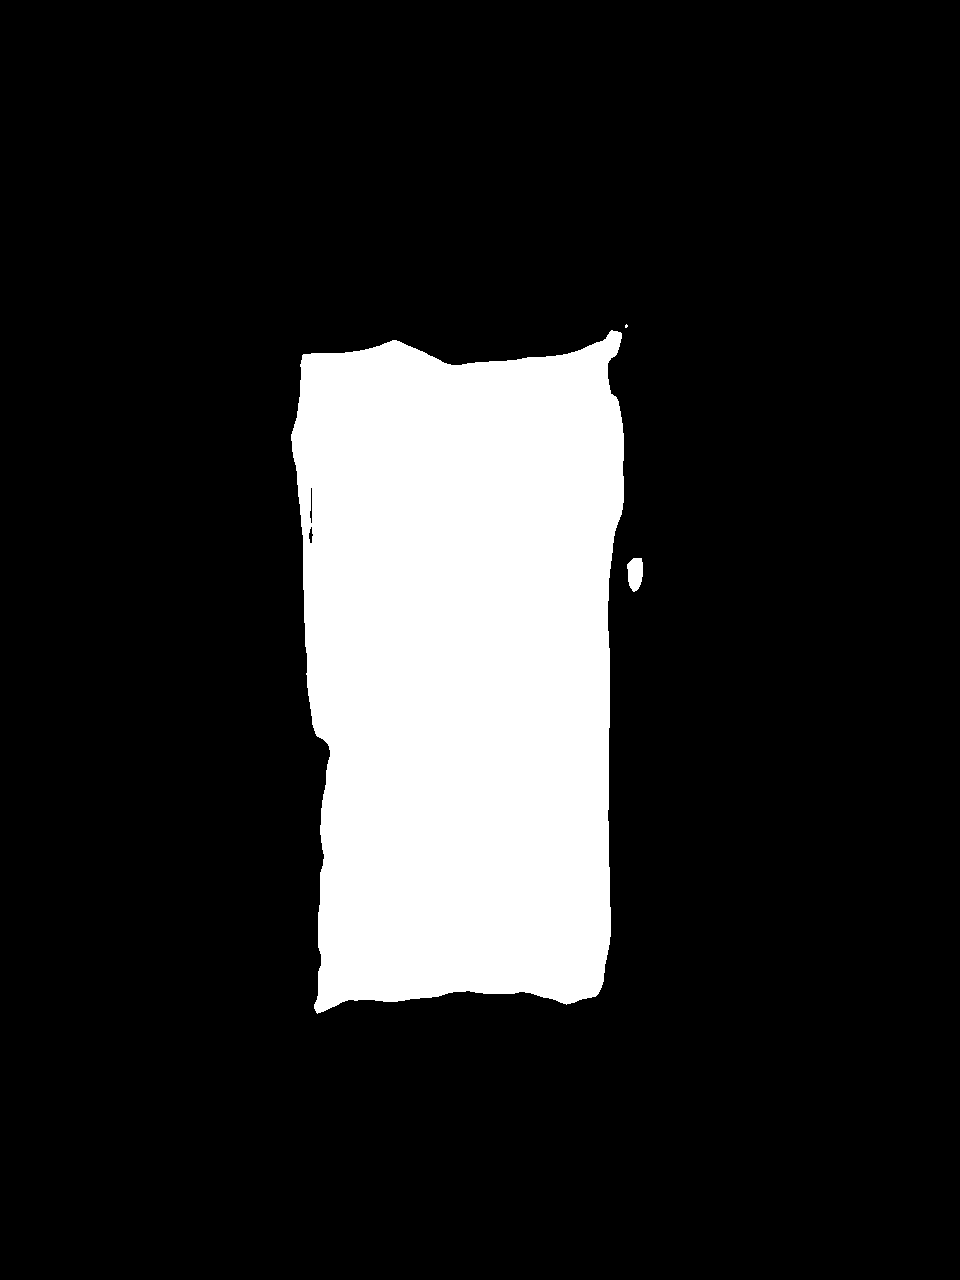

In [18]:
door_mask = output[3]['mask']
door_mask.save("door_mask.jpg")
print(door_mask.size)
print(np.array(door_mask).shape)
door_mask

In [19]:
door_mask2 = np.swapaxes(np.array(door_mask), 0, 1)
door_mask_img = Image.fromarray(door_mask2)
door_mask_img2 = door_mask_img.transpose(Image.FLIP_TOP_BOTTOM)
door_mask_flip = np.array(door_mask_img2)
#Image.fromarray(door_mask_flip)

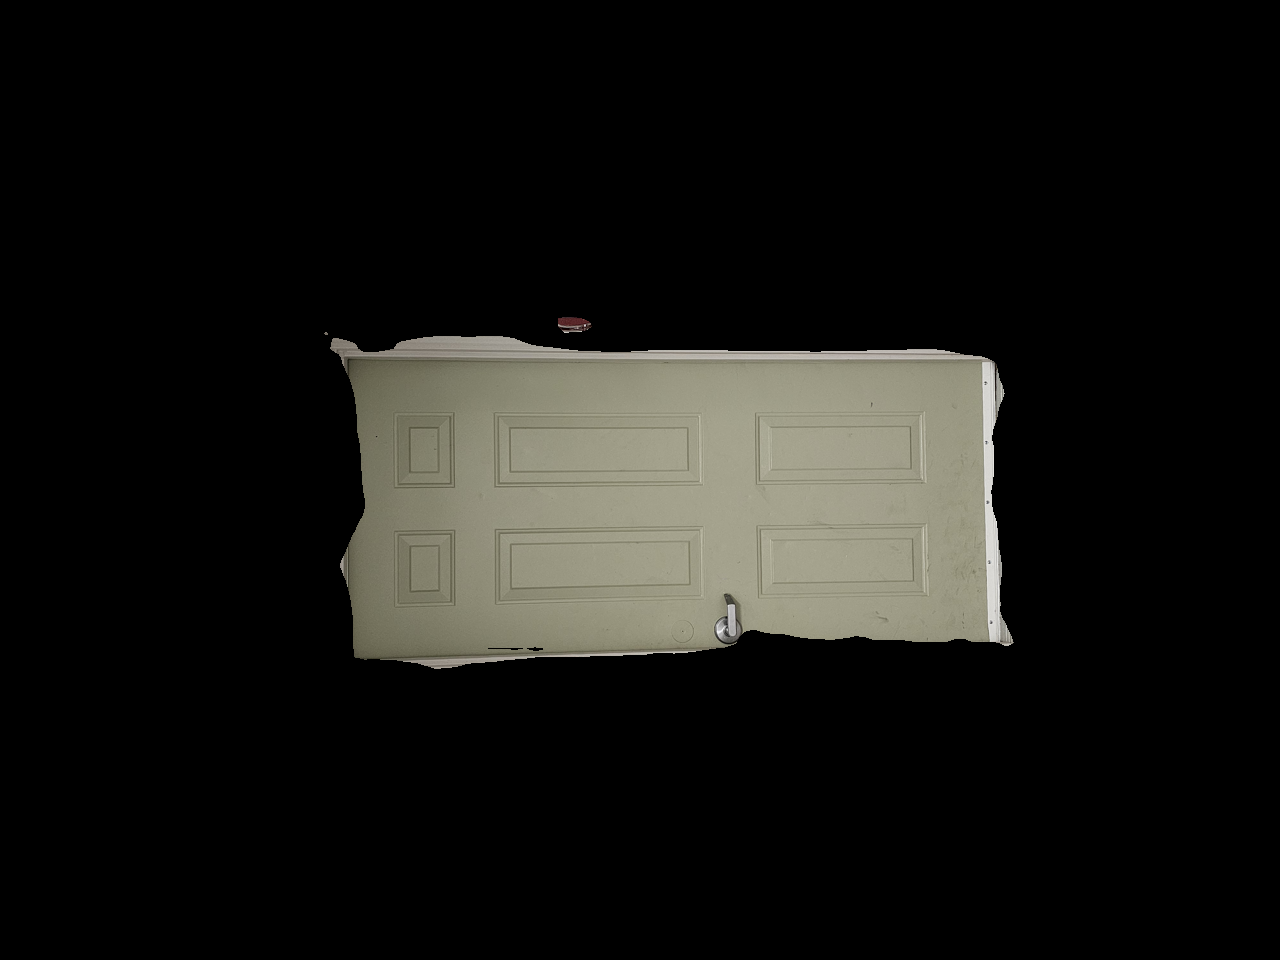

In [20]:
new_img_arr = np.expand_dims(door_mask_flip, axis=2) / 255 * np.array(image)
new_img_arr2 = new_img_arr.astype(np.uint8)
Image.fromarray(new_img_arr2)

## Extract the Door Affordances

### Prep Input Data and Model

In [23]:
## Set up configuration
dict1 = None
with open("threedoi/monoarti/configs/merged.yaml", "r") as yamlfile:
    dict1 = yaml.load(yamlfile, Loader=yaml.FullLoader)

dict_config = OmegaConf.create(dict1)
#print(dict_config)

In [24]:
## Build model and load pretrained weights
model = build_model(dict_config)
loaded_data = torch.load("checkpoint_20230515.pth", map_location="cpu")
state_dict = loaded_data["model"]
model.load_state_dict(state_dict, strict=False)

C:\Users\ITP User\AppData\Local\Temp\ipykernel_9992\1447835829.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_data = torch.load("checkpoint_20230515.pth", map_lo

<All keys matched successfully>

In [25]:
## Get prediction
# Prepare image tensor
# convert PIL Image to pytorch tensors
transform = transforms.ToTensor()
image_tensor = image.convert("RGB")
image_tensor2 = transform(image_tensor).unsqueeze(0)
w, z, x, y = image_tensor2.size()

# Get keypoint for door
# Calculate moments
door_mask_np = np.array(door_mask)
M = cv2.moments(door_mask_np)

# Calculate centroid
cX = 0
cY = 0
if M["m00"] != 0:
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
cX_f = cX / x
cY_f = cY / y
print(cX_f, cY_f)

# Inputs
valid = torch.tensor([[1]])
keypoints = torch.tensor([[[cX_f, cY_f]]])
bbox = torch.tensor([[[0.31875, 0.8430555555555556, 0.36796875, 1.0]]])
masks = torch.tensor([[[[0.32103523851670296, 0.9633147135119159], [0.32171800998020555, 0.9471305010437062], [0.32578431696752774, 0.9230338670447602], [0.32641163517430355, 0.9199669780338562], [0.3307330637346389, 0.9053701526745013], [0.3307330637346389, 0.8995211696686322], [0.33338284248884736, 0.8881369350209218], [0.33369944771890236, 0.8735027377206025], [0.3318518283167389, 0.8609115536465994], [0.33211989005036585, 0.8563842888120101], [0.33251576399322724, 0.8512232655569284], [0.3527435773373113, 0.848654654338632], [0.3557932636013182, 0.8487279200747042], [0.35586906115475164, 0.8509288564410684], [0.35357140828920475, 0.8767987257420403], [0.35455329934773633, 0.8843629235262834], [0.3542787876724764, 0.8909512037325216], [0.3571282347429713, 0.9027711323212411], [0.3599776818134661, 0.9224710133024402], [0.36203005442052544, 0.9420825737698958], [0.36203005442052544, 0.950482932041545], [0.36118418980739336, 0.9955957114085886], [0.32103523851670296, 0.9941390601145954]]]])
movable = torch.tensor([[0]])
rigid = torch.tensor([[0]])
kinematic = torch.tensor([[0]])
action = torch.tensor([[0]])
affordance = torch.tensor([[[0.340625, 0.9291666666666667]]])
affordance_map = torch.tensor([[[0.340625, 0.9291666666666667]]])
depth = torch.tensor([[0]])
axis = torch.tensor([[[-1, -1, -1, -1]]])
fov = torch.tensor([[0]])

0.4791666666666667 0.5203125


### Input into Model

In [27]:
# Input into model
model.eval()
output = None
with torch.no_grad():
    output = model(image_tensor2, valid, keypoints, bbox, masks, movable, rigid, kinematic, action, affordance, affordance_map, depth, axis, fov, backward=False)

In [28]:
print(output)
out = output

{'pred_boxes': tensor([[[0.0059, 0.0052, 0.1826, 0.9609]]]), 'pred_movable': tensor([[[ 12.4747, -10.0524, -18.9647]]]), 'pred_rigid': tensor([[[-7.5242,  7.9166]]]), 'pred_kinematic': tensor([[[-3.4511,  5.1446, -4.0308]]]), 'pred_action': tensor([[[ -6.2621,  13.8623, -14.8645]]]), 'pred_masks': tensor([[[[ -8.5248,  -8.5248,  -8.8331,  ..., -12.7483, -12.7122, -12.7122],
          [ -8.2946,  -8.2946,  -8.5800,  ..., -12.7548, -12.7240, -12.7240],
          [ -7.1435,  -7.1435,  -7.3146,  ..., -12.7873, -12.7829, -12.7829],
          ...,
          [ -9.8088,  -9.8088,  -9.6538,  ..., -11.2179, -11.2436, -11.2436],
          [ -9.7070,  -9.7070,  -9.7560,  ..., -11.8156, -11.8761, -11.8761],
          [-10.9515, -10.9515, -11.0535,  ..., -14.3542, -14.3292, -14.3292]]]]), 'pred_axis': tensor([[[-0.0272,  1.4214,  0.0428]]]), 'pred_depth': tensor([[[[0.1116, 0.1116, 0.1133,  ..., 0.1751, 0.1748, 0.1748],
          [0.1120, 0.1120, 0.1136,  ..., 0.1755, 0.1752, 0.1752],
          [0.1

In [29]:
#data = torch.load("data_test.pt")
#print(data[0])

### Parse output

In [31]:
image_size = (x, y)
mask_preds = out['pred_masks']
mask_preds = interpolate(mask_preds, size=image_size, mode='bilinear', align_corners=False)
mask_preds = mask_preds.sigmoid() > 0.5
movable_preds = out['pred_movable'].argmax(dim=-1)
rigid_preds = out['pred_rigid'].argmax(dim=-1)
kinematic_preds = out['pred_kinematic'].argmax(dim=-1)
action_preds = out['pred_action'].argmax(dim=-1)
axis_preds = out['pred_axis']
depth_preds = out['pred_depth']
affordance_preds = out['pred_affordance']
affordance_preds = interpolate(affordance_preds, size=image_size, mode='bilinear', align_corners=False)

In [155]:
vis = np.array(image).copy()
vis = cv2.circle(vis, (cY, cX), 24, (255, 255, 255), -1)
vis_img = Image.fromarray(vis)
vis_img.save("door_feature.jpg")

In [33]:
# physical properties
movable_imap = {
    0: 'one_hand',
    1: 'two_hands',
    2: 'fixture',
    -100: 'n/a',
}

rigid_imap = {
    1: 'yes',
    0: 'no',
    2: 'bad',
    -100: 'n/a',
}

kinematic_imap = {
    0: 'freeform',
    1: 'rotation',
    2: 'translation',
    -100: 'n/a'
}

action_imap = {
    0: 'free',
    1: 'pull',
    2: 'push',
    -100: 'n/a',
}

i = 0
j = 0
movable_pred = movable_preds[i, j].item()
rigid_pred = rigid_preds[i, j].item()
kinematic_pred = kinematic_preds[i, j].item()
action_pred = action_preds[i, j].item()

print(movable_imap[movable_pred])
print(rigid_imap[rigid_pred])
print(kinematic_imap[kinematic_pred])
print(action_imap[action_pred])

one_hand
yes
rotation
pull


In [34]:
#door = mask_preds[0][0].unsqueeze(2) * np.array(image)
#door_arr = np.array(door)
#Image.fromarray(door_arr)

In [35]:
print(axis_preds)
line_x = [
    int(np.abs(axis_preds[0][0][0] * x)),
    int(np.abs(axis_preds[0][0][1] * x)),
] 
line_y = [
    int(np.abs(axis_preds[0][0][2] * y)),
    int(np.abs(axis_preds[0][0][2] * y)),
] 
print(line_x, line_y)

#vis = np.array(image).copy()
#vis = cv2.line(vis, (line_x[0], line_y[0]), (line_x[1], line_y[1]), (255, 255, 255), 9)
#Image.fromarray(vis)

tensor([[[-0.0272,  1.4214,  0.0428]]])
[26, 1364] [54, 54]


C:\Users\ITP User\AppData\Local\Temp\ipykernel_9992\2674521775.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  int(np.abs(axis_preds[0][0][0] * x)),
C:\Users\ITP User\AppData\Local\Temp\ipykernel_9992\2674521775.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  int(np.abs(axis_preds[0][0][1] * x)),
C:\Users\ITP User\AppData\Local\Temp\ipykernel_9992\2674521775.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  int(np.abs(axis_preds[0][0][2] * y)),
C:\Users\ITP User\AppData\Local\Temp\ipykernel_9992\2674521775.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  int(np.abs(axis_preds[0][0][2] * y)),


In [157]:
line_x2 = [line_x[0] + 300, line_x[1] - 300]
line_y2 = [line_y[0] + 300, line_y[1] + 300]

vis = np.array(image).copy()
vis = cv2.line(vis, (line_x2[0], line_y2[0]), (line_x2[1], line_y2[1]), (255, 255, 255), 9)
vis_img2 = Image.fromarray(vis)
vis_img2.save("door_axis.jpg")

## Warp the Door

### Get bounding box for door

In [39]:
# Find contours
contours, _ = cv2.findContours(door_mask_flip, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Initialize a list to store bounding boxes
bounding_boxes = []
i_max = 0
max_val = 0
count = 0

# Loop through contours and calculate bounding boxes
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    #print(x, y, w, h)
    bounding_boxes.append((x, y, x + w, y + h))  # (x1, y1, x2, y2)
    if w + h > max_val:
        i_max = count
        max_val = w + h
    count = count + 1

bounding_boxes = np.array(bounding_boxes)
#print(bounding_boxes)

# Extract the tuple with the largest sum
bbox = bounding_boxes[i_max]
print(bbox)

[ 330  336 1014  669]


In [159]:
roi = np.array(image)[bbox[1] : bbox[3], bbox[0] : bbox[2], :]
print(roi.shape)
roi_img = Image.fromarray(roi)
roi_img.save("roi_img.jpg")

(333, 684, 3)


### Warp source points to make the door open

In [161]:
# Define source points (corners of the ROI)
roi_w, roi_h, z = roi.shape
src_points = np.float32([[0, 0], [roi_h, 0], [roi_h, roi_w], [0, roi_w]])
print(src_points)

# Door rotation
rotation_angle = 45
theta = np.radians(rotation_angle)
sens = 0.1

# Define the destination points to simulate the opening effect
# Adjust these points to create the desired opening effect
corn21 = [src_points[0][0] * 1, src_points[0][1] * 1]
corn22 = [src_points[1][0] * 1, src_points[1][1] * 1]
corn23 = [src_points[2][0] * (1 - sens * np.sin(theta)), roi_w * np.cos(theta)]
corn24 = [src_points[3][0] + sens * roi_h * np.sin(theta), roi_w * np.cos(theta)]
dst_points = np.float32([corn21, corn22, corn23, corn24])
print(src_points[3][1] * 0.5)
print(dst_points)

# Get the perspective transformation matrix
homo_matrix = cv2.getPerspectiveTransform(src_points, dst_points)

[[  0.   0.]
 [684.   0.]
 [684. 333.]
 [  0. 333.]]
166.5
[[  0.         0.      ]
 [684.         0.      ]
 [635.6339   235.46655 ]
 [ 48.366104 235.46655 ]]


In [163]:
## Get door img
door_img_arr = new_img_arr2

# Apply the warp
warped_image = cv2.warpPerspective(roi, homo_matrix, (roi_h, roi_w))

# Display the result
print(warped_image.shape)
door_warp_pil = Image.fromarray(warped_image)
door_warp_pil.save("roi_warp.jpg")

(333, 684, 3)


## Put it all together

### Background image

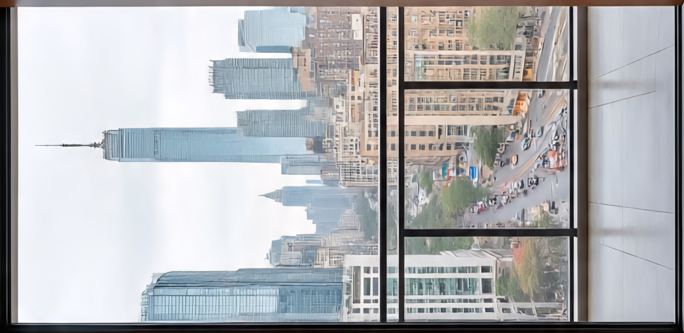

In [96]:
## Open and transform the Image
back_img = Image.open("background.jpg")
back_img = back_img.resize((roi_w, roi_h))
back_img_arr = np.swapaxes(np.array(back_img), 0, 1)
back_img2 = Image.fromarray(back_img_arr)
back_img3 = back_img2.transpose(Image.FLIP_TOP_BOTTOM)
back_img_arr_flip = np.array(back_img3)
Image.fromarray(back_img_arr_flip)

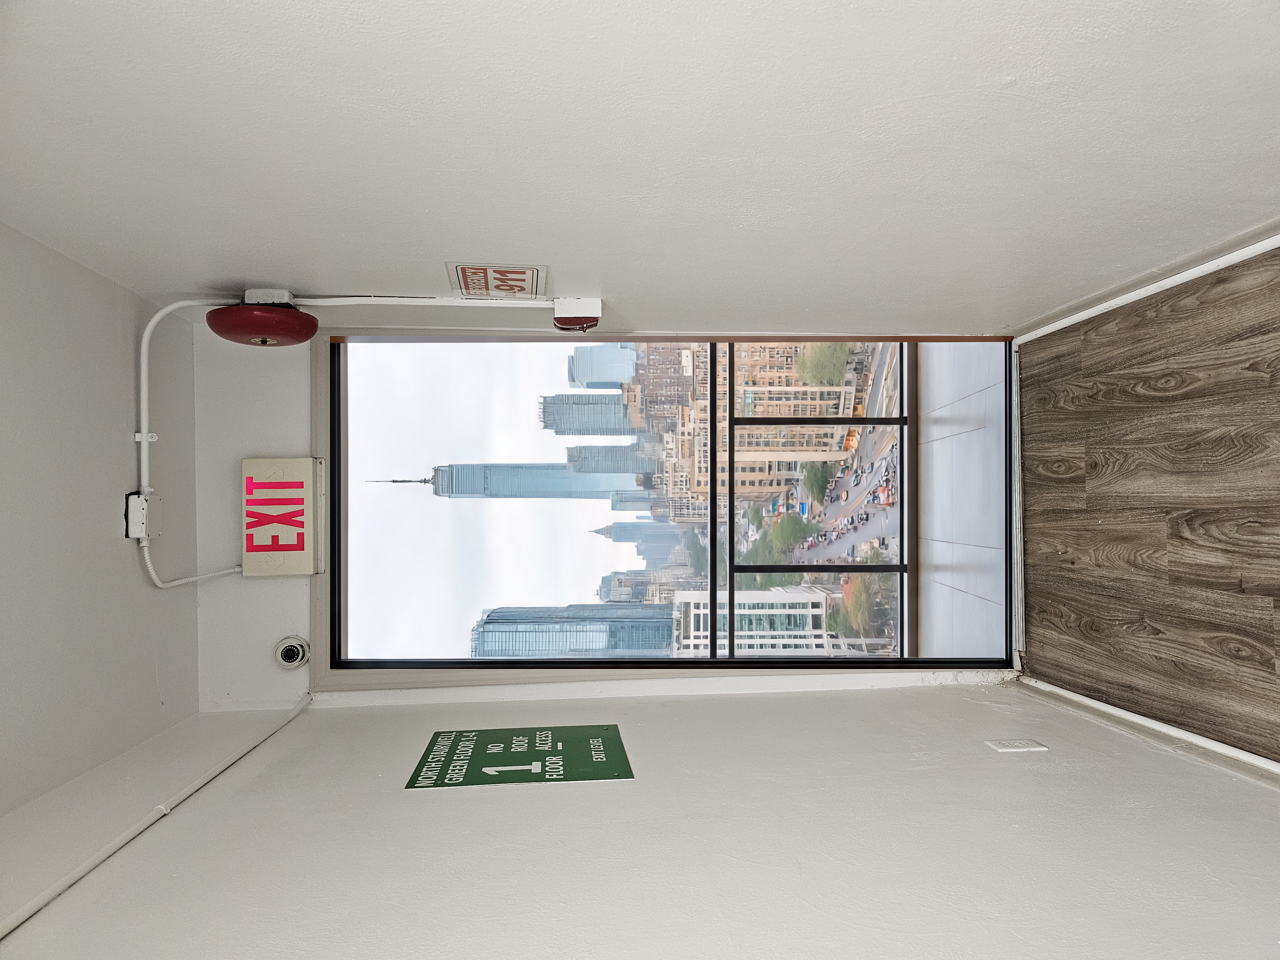

In [98]:
# Add the background image in
image_arr = np.array(image)
image_arr[bbox[1] : bbox[3], bbox[0] : bbox[2], :] = back_img_arr_flip
Image.fromarray(image_arr)

In [100]:
# Load the Stable Diffusion model
"""
pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)
"""

'\npipe = StableDiffusionPipeline.from_pretrained(\n    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16\n)\n'

In [102]:
"""
# Set the prompt and desired size
prompt = "Something that would be behind a door"
height = np.ceil(roi_h / 8) * 8  # Desired height
width = np.ceil(roi_w / 8) * 8   # Desired width

# Generate the image
with torch.no_grad():
    image = pipe(prompt, height=height, width=width).images[0]

# Save or display the generated image
image.save("generated_image.png")
"""

'\n# Set the prompt and desired size\nprompt = "Something that would be behind a door"\nheight = np.ceil(roi_h / 8) * 8  # Desired height\nwidth = np.ceil(roi_w / 8) * 8   # Desired width\n\n# Generate the image\nwith torch.no_grad():\n    image = pipe(prompt, height=height, width=width).images[0]\n\n# Save or display the generated image\nimage.save("generated_image.png")\n'

### Add the Door back in

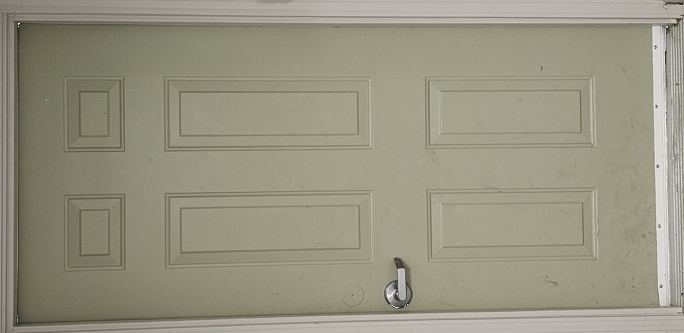

In [105]:
## Combine warped door image and background
# Create a mask where black areas are detected in the warped door image
warped_image_gray = cv2.cvtColor(warped_image, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(warped_image_gray, 30, 255, cv2.THRESH_BINARY_INV)

# Create a mask for the insert background image
insert_mask = cv2.cvtColor(back_img_arr_flip, cv2.COLOR_RGB2GRAY)
_, insert_mask = cv2.threshold(insert_mask, 30, 255, cv2.THRESH_BINARY)

# Invert the mask to get the areas to keep from the warped door image
inverse_mask = cv2.bitwise_not(mask)

# Use the masks to combine the images
original_part = cv2.bitwise_and(warped_image, warped_image, mask=inverse_mask)
insert_part = cv2.bitwise_and(back_img_arr_flip, back_img_arr_flip, mask=mask)

# Combine the two parts
result_image = cv2.add(original_part, insert_part)
Image.fromarray(result_image)

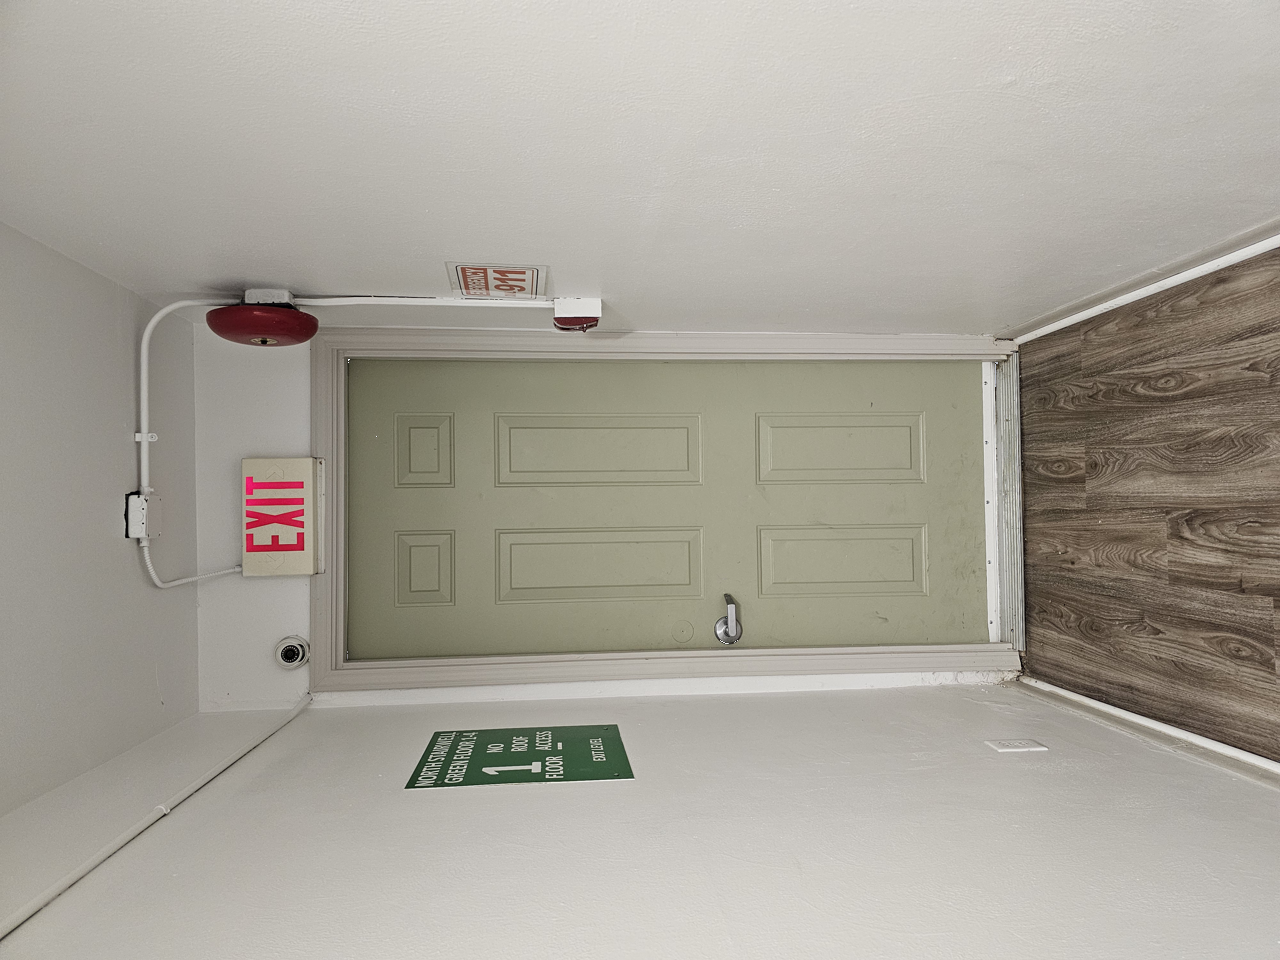

In [107]:
## Add door back into original image
image_arr[bbox[1] : bbox[3], bbox[0] : bbox[2], :] = result_image
result = Image.fromarray(image_arr)
result.save("result_" + str(rotation_angle) + ".jpg")
result

### Create video

In [144]:
def create_result_imgs():
    rot_angle_arr = np.linspace(0, 90, 91)
    for i in range(len(rot_angle_arr)):
        # Define source points (corners of the ROI)
        roi_w, roi_h, z = roi.shape
        src_points = np.float32([[0, 0], [roi_h, 0], [roi_h, roi_w], [0, roi_w]])
        
        # Door rotation
        rotation_angle = rot_angle_arr[i]
        theta = np.radians(rotation_angle)
        sens = 0.1
        
        # Define the destination points to simulate the opening effect
        # Adjust these points to create the desired opening effect
        corn21 = [src_points[0][0] * 1, src_points[0][1] * 1]
        corn22 = [src_points[1][0] * 1, src_points[1][1] * 1]
        corn23 = [src_points[2][0] * (1 - sens * np.sin(theta)), roi_w * np.cos(theta)]
        corn24 = [src_points[3][0] + sens * roi_h * np.sin(theta), roi_w * np.cos(theta)]
        dst_points = np.float32([corn21, corn22, corn23, corn24])
        
        # Get the perspective transformation matrix
        homo_matrix = cv2.getPerspectiveTransform(src_points, dst_points)
    
        ## Get door img
        door_img_arr = new_img_arr2
        
        # Apply the warp
        warped_image = cv2.warpPerspective(roi, homo_matrix, (roi_h, roi_w))
        
        # Display the result
        Image.fromarray(warped_image)
    
        # Add the background image in
        image_arr = np.array(image)
        image_arr[bbox[1] : bbox[3], bbox[0] : bbox[2], :] = back_img_arr_flip
        Image.fromarray(image_arr)
    
        ## Combine warped door image and background
        # Create a mask where black areas are detected in the warped door image
        warped_image_gray = cv2.cvtColor(warped_image, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(warped_image_gray, 30, 255, cv2.THRESH_BINARY_INV)
        
        # Create a mask for the insert background image
        insert_mask = cv2.cvtColor(back_img_arr_flip, cv2.COLOR_RGB2GRAY)
        _, insert_mask = cv2.threshold(insert_mask, 30, 255, cv2.THRESH_BINARY)
        
        # Invert the mask to get the areas to keep from the warped door image
        inverse_mask = cv2.bitwise_not(mask)
        
        # Use the masks to combine the images
        original_part = cv2.bitwise_and(warped_image, warped_image, mask=inverse_mask)
        insert_part = cv2.bitwise_and(back_img_arr_flip, back_img_arr_flip, mask=mask)
        
        # Combine the two parts
        result_image = cv2.add(original_part, insert_part)
        Image.fromarray(result_image)
    
        ## Add door back into original image
        image_arr[bbox[1] : bbox[3], bbox[0] : bbox[2], :] = result_image
        result = Image.fromarray(image_arr)
        angle_str = str(int(rotation_angle)) if rotation_angle >= 10 else "0" + str(int(rotation_angle))
        result.save("output/" + angle_str + "result.jpg")
        result

In [146]:
create_result_imgs()

In [150]:
# Function to generate video
def generate_video():
    image_folder = "output"
    video_name = 'door_opening.mp4'

    images = [img for img in os.listdir(image_folder) if img.endswith((".jpg", ".jpeg", ".png"))]
    print("Images:", images)

    # Set frame from the first image
    frame = cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = frame.shape

    # Video writer to create .avi file
    video = cv2.VideoWriter(video_name, cv2.VideoWriter_fourcc(*'H264'), 30, (width, height))

    # Appending images to video
    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))

    # Release the video file
    video.release()
    cv2.destroyAllWindows()
    print("Video generated successfully!")

# Calling the function to generate the video
generate_video()

Images: ['00result.jpg', '01result.jpg', '02result.jpg', '03result.jpg', '04result.jpg', '05result.jpg', '06result.jpg', '07result.jpg', '08result.jpg', '09result.jpg', '10result.jpg', '11result.jpg', '12result.jpg', '13result.jpg', '14result.jpg', '15result.jpg', '16result.jpg', '17result.jpg', '18result.jpg', '19result.jpg', '20result.jpg', '21result.jpg', '22result.jpg', '23result.jpg', '24result.jpg', '25result.jpg', '26result.jpg', '27result.jpg', '28result.jpg', '29result.jpg', '30result.jpg', '31result.jpg', '32result.jpg', '33result.jpg', '34result.jpg', '35result.jpg', '36result.jpg', '37result.jpg', '38result.jpg', '39result.jpg', '40result.jpg', '41result.jpg', '42result.jpg', '43result.jpg', '44result.jpg', '45result.jpg', '46result.jpg', '47result.jpg', '48result.jpg', '49result.jpg', '50result.jpg', '51result.jpg', '52result.jpg', '53result.jpg', '54result.jpg', '55result.jpg', '56result.jpg', '57result.jpg', '58result.jpg', '59result.jpg', '60result.jpg', '61result.jpg',